In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'Machine_Learning_lab', 'USA_Housing.csv']

In [3]:
import os
os.listdir("/content/drive/MyDrive/Machine_Learning_lab")

['winequality.names', 'winequality-red.csv', 'winequality-white.csv']

In [5]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/USA_Housing.csv')
df.head()
df.shape

(5000, 7)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['Price', 'Address'], axis=1)
y = df['Price']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Testing set size: {X_test_scaled.shape[0]}")
print("Data preprocessing complete - features scaled")

Training set size: 4000
Testing set size: 1000
Data preprocessing complete - features scaled


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.8f}")

# Additional metrics
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.4f}")

# Sample predictions
print("\nSample predictions (first 10):")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Error': np.abs(y_test.values[:10] - y_pred[:10])
})
print(comparison)

Mean Squared Error: 10089009300.89398956
Root Mean Squared Error: 100444.0606

Sample predictions (first 10):
         Actual     Predicted          Error
0  1.339096e+06  1.308588e+06   30508.150248
1  1.251794e+06  1.237037e+06   14756.949343
2  1.340095e+06  1.243429e+06   96665.625899
3  1.431508e+06  1.228900e+06  202607.409824
4  1.042374e+06  1.063321e+06   20947.383012
5  1.555321e+06  1.544058e+06   11262.449653
6  1.250882e+06  1.094775e+06  156107.586827
7  1.039381e+06  8.332847e+05  206095.999087
8  8.324752e+05  7.884129e+05   44062.333228
9  1.420648e+06  1.469715e+06   49066.585287


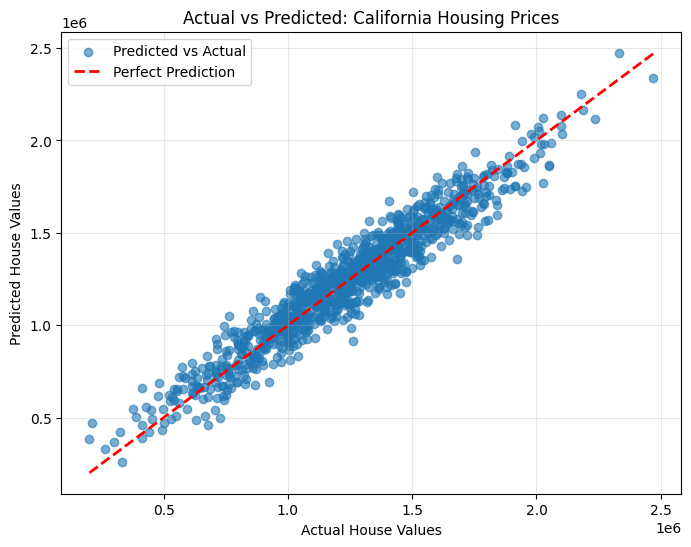

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title('Actual vs Predicted: California Housing Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()